# How to read CAFVRPILA instances

In [78]:
import json
import networkx as nx
import matplotlib.pyplot as plt

import os
DIR_INSTANCES  = os.path.join(os.getcwd(), 'Instances')
DIR_SOLUTIONS  = os.path.join(os.getcwd(), 'Solutions') 

## Get the instance

In [79]:
instance_name = "Instance_4.json" # Capacity 100, Implement depots +DI, Vehicles 10, autonomy 1000, Depots +DV
instance_dir  = os.path.join(DIR_INSTANCES, instance_name)
with open(instance_dir, 'r') as f:
    instance_data = json.load(f)

instance_data.keys()

dict_keys(['Operations', 'Vehicles', 'Implements', 'Tasks', 'Depots', 'Coords', 'Vehicle_autonomy', 'Vehicle_depot', 'Vehicle_cost', 'Implement_capacity', 'Implement_depot', 'Implement_cost', 'Task_Demands', 'Implements_per_operation', 'Implements_per_vehicle', 'Tasks_per_operation'])

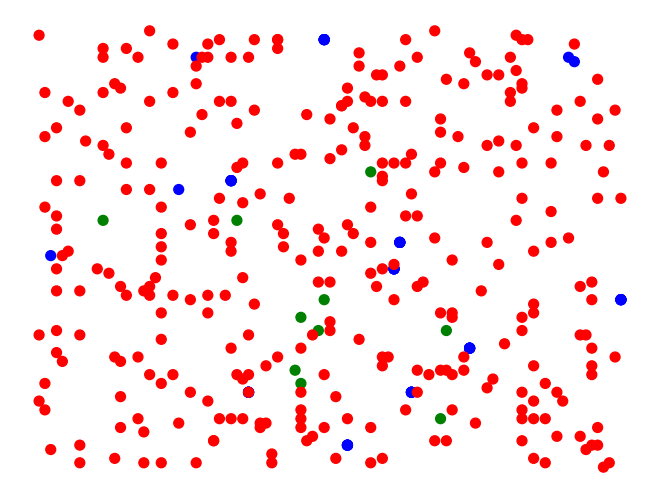

In [12]:
# Create a graph
G = nx.Graph()

# Add nodes with positions
for node, coords in instance_data['Coords'].items():
    G.add_node(node, pos=coords)

# Draw the graph
pos = nx.get_node_attributes(G, 'pos')
# Color nodes based on their type
node_colors = ['red' if node.startswith('Task') else 'blue' if node.startswith('Depot_Implement') else 'green' if node.startswith('Depot_Vehicle') else 'skyblue' for node in G.nodes()]
# Plot the graph
nx.draw(G, pos, with_labels=False, node_size=50, node_color=node_colors, font_size=10, font_weight='bold')
plt.show()

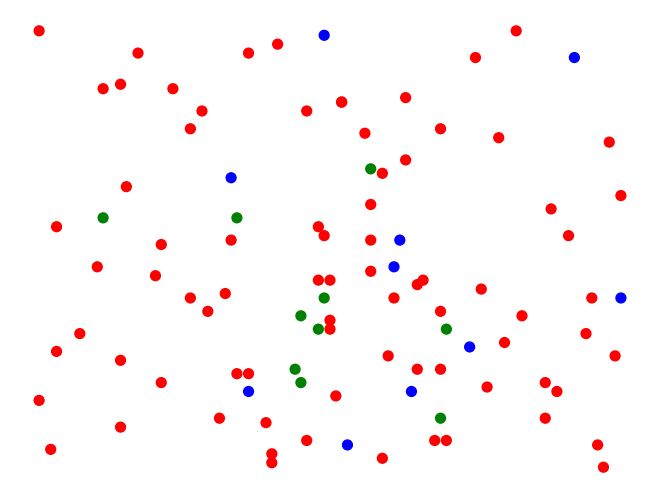

In [18]:
# Plot only one operation
operation = "Operation_1"
tasks_per_operation = instance_data['Tasks_per_operation'][operation]
implements_per_operation = instance_data['Implements_per_operation'][operation]
implements_per_operation_depots = [ instance_data['Implement_depot'][implement] for implement in implements_per_operation]
vehicles_per_operation = instance_data["Vehicles"]
vehicle_per_operation_depots = [ instance_data['Vehicle_depot'][vehicle] for vehicle in vehicles_per_operation]

# Create a graph
G = nx.Graph()

# Add nodes with positions
nodes = tasks_per_operation + implements_per_operation_depots + vehicle_per_operation_depots
for node in nodes :
    coords = instance_data['Coords'][node]
    G.add_node(node, pos=coords)

# Draw the graph
pos = nx.get_node_attributes(G, 'pos')
# Color nodes based on their type
node_colors = ['red' if node.startswith('Task') else 'blue' if node.startswith('Depot_Implement') else 'green' if node.startswith('Depot_Vehicle') else 'skyblue' for node in G.nodes()]
# Plot the graph
nx.draw(G, pos, with_labels=False, node_size=50, node_color=node_colors, font_size=10, font_weight='bold')
plt.show()

## Get solution

In [38]:
solution_name = "Solutions_util_util/Instance_4.json.sol.json" # Capacity 100, Implement depots +DI, Vehicles 10, autonomy 1000, Depots +DV
solution_dir  = os.path.join(DIR_SOLUTIONS, solution_name)
with open(solution_dir, 'r') as f:
    solution_data = json.load(f)

solution_data.keys()

dict_keys(['Vehicle_7', 'Vehicle_2', 'Vehicle_6', 'Vehicle_3', 'Vehicle_10', 'Vehicle_1', 'Vehicle_4', 'Vehicle_9', 'Vehicle_8', 'Vehicle_5', 'Implement_1', 'Implement_2', 'Implement_3', 'Implement_4', 'Implement_5', 'Implement_6', 'Implement_7', 'Implement_8', 'Implement_9', 'Implement_10', 'Implement_11', 'Implement_12', 'Implement_13', 'Implement_14', 'Implement_15', 'Implement_16', 'Implement_17', 'Implement_18', 'Implement_19', 'Implement_20', 'Implement_21', 'Implement_22', 'Implement_23', 'Implement_24', 'Implement_25', 'Implement_26', 'Implement_27', 'Implement_28', 'Implement_29', 'Implement_30', 'Implement_31', 'Implement_32', 'Implement_33', 'Implement_34', 'Implement_35', 'Implement_36', 'Implement_37', 'Implement_38', 'Implement_39', 'Implement_40', 'Implement_41', 'Implement_42', 'Implement_43', 'Implement_44', 'Implement_45', 'Implement_46', 'Implement_47', 'Implement_48', 'Implement_49', 'Implement_50'])

In [76]:
vehicle_name = "Vehicle_4"
vehicle_route = solution_data[vehicle_name]

# Con un pelin de trampa
implement_used_in_route  = list({node for node in vehicle_route if 'Implement' in node})
implement_used_in_route = [implement.replace("Depot_", "") for implement in implement_used_in_route]
implement_used_routes = {implement: solution_data[implement] for implement in implement_used_in_route}

print(f"Route of {vehicle_name}: {vehicle_route}")
for implement, route in implement_used_routes.items():
    print(f"Route of {implement}: {route}")

Route of Vehicle_4: ['Depot_Vehicle_4', 'Depot_Implement_21', 'Task_169', 'Task_156', 'Task_161', 'Task_151', 'Task_192', 'Task_148', 'Depot_Implement_21', 'Depot_Vehicle_4']
Route of Implement_21: ['Depot_Implement_21', 'Task_169', 'Task_156', 'Task_161', 'Task_151', 'Task_192', 'Task_148', 'Depot_Implement_21']


Print route with routes

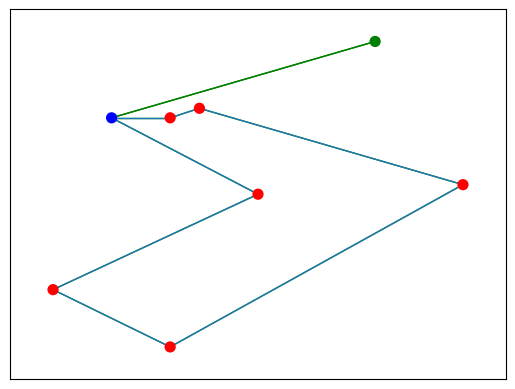

In [77]:
nodes = list(set(vehicle_route))

# Create a graph
G = nx.Graph()

# Add nodes with positions
for node in nodes:
    coords = instance_data['Coords'][node]
    G.add_node(node, pos=coords)

# Draw the graph
pos = nx.get_node_attributes(G, 'pos')
node_colors = ['red' if node.startswith('Task') else 'blue' if node.startswith('Depot_Implement') else 'green' if node.startswith('Depot_Vehicle') else 'skyblue' for node in G.nodes()]

# Plot the nodes
nx.draw_networkx_nodes(G, pos, nodelist=nodes, node_color=node_colors, node_size=50)


nx.draw_networkx_edges(G, pos, edgelist=list(zip(vehicle_route[:-1], vehicle_route[1:])), edge_color="green", width=1)

# If there are more implements than colors, we will cycle through the colors
import matplotlib.colors as mcolors
import itertools
colors = mcolors.TABLEAU_COLORS.keys()
colors_cycle = itertools.cycle(colors)
color_implement = {implement: next(colors_cycle) for implement in implement_used_routes.keys()}

for implement, route in implement_used_routes.items():
    # Get a unique color for each route
    nx.draw_networkx_edges(G, pos, edgelist=list(zip(route[:-1], route[1:])), edge_color=color_implement[implement], width=1)

plt.show()